# Практическое занятие №5
## Контролируемое обучение (Supervised Learning)
### Выполнил Дмитрий Трифонов, 12-25РПМ, 1 курс, Программная инженерия

Этот ноутбук предназначен для выполнения ПЗ‑5 по лекции 3.1.

**Важно:** каждый студент выполняет работу по *своему варианту* (CSV‑файлу). Предполагается, что ноутбук и файлы данных находятся **в одной папке**.

## Как работать с ноутбуком

1. В ячейке **«Номер варианта»** укажите `VARIANT` от 1 до 15.
2. Запустите ноутбук сверху вниз.
3. В текстовых ячейках (где написано *«Ответ студента»*) впишите свои пояснения.

В конце у вас должен получиться отчёт: постановка задачи, описание данных, обучение модели, метрики, анализ переобучения и выводы.

In [18]:
# Ячейка 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    mean_squared_error, mean_absolute_error
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
print('Библиотеки успешно импортированы.')

Библиотеки успешно импортированы.


In [19]:
# Ячейка 2. Номер варианта и загрузка данных
# УКАЖИТЕ НОМЕР СВОЕГО ВАРИАНТА (1–15)
VARIANT = 12

# Имя файла по шаблону: dataset_variant_1.csv, dataset_variant_2.csv, ...
filename = f"6-0_dataset_variant_{VARIANT}.csv"
print('Открываю файл:', filename)

df = pd.read_csv(filename)
display(df.head())
print('\nРазмер таблицы:', df.shape)

Открываю файл: 6-0_dataset_variant_12.csv


,area_m2,rooms,floor,distance_center_km,year_built,schools_1km,parks_1km,metro_minutes,renovation_score,noise_db,target
0,53.7,3,8,8.42,1966,2,3,22.2,6.4,42.6,10.162
1,73.9,2,2,18.82,1983,1,3,13.0,5.1,48.8,9.843
2,95.3,4,7,4.68,2020,3,1,16.5,5.3,57.8,12.810
3,34.1,3,10,7.93,1989,1,0,21.7,6.2,57.3,7.765
4,83.6,1,13,1.11,2024,1,2,23.8,4.3,52.5,5.805



Размер таблицы: (500, 11)


## 1. Первичный анализ данных (обязательный)

На этом шаге вы должны понять:
- какие столбцы есть в данных;
- какие типы данных у столбцов;
- есть ли пропуски;
- есть ли очевидные аномалии.


In [20]:
# Ячейка 3. Информация о данных
df.info()
print('\nЧисло пропусков по столбцам:')
display(df.isna().sum())

print('\nОписательная статистика по числовым столбцам:')
display(df.describe(include=[np.number]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area_m2             500 non-null    float64
 1   rooms               500 non-null    int64  
 2   floor               500 non-null    int64  
 3   distance_center_km  500 non-null    float64
 4   year_built          500 non-null    int64  
 5   schools_1km         500 non-null    int64  
 6   parks_1km           500 non-null    int64  
 7   metro_minutes       500 non-null    float64
 8   renovation_score    500 non-null    float64
 9   noise_db            500 non-null    float64
 10  target              500 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 43.1 KB

Число пропусков по столбцам:


area_m2               0
rooms                 0
floor                 0
distance_center_km    0
year_built            0
schools_1km           0
parks_1km             0
metro_minutes         0
renovation_score      0
noise_db              0
target                0
dtype: int64


Описательная статистика по числовым столбцам:


,area_m2,rooms,floor,distance_center_km,year_built,schools_1km,parks_1km,metro_minutes,renovation_score,noise_db,target
count,500.000000,500.00000,500.00000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,61.900200,2.72000,7.13400,8.90844,1995.692000,1.964000,1.550000,18.192400,6.071800,51.882400,9.765754
std,18.110701,1.05443,3.22814,3.79385,16.539778,1.260906,1.144605,6.314029,1.417181,5.920249,5.455896
min,20.000000,1.00000,1.00000,0.50000,1950.000000,0.000000,0.000000,2.000000,1.600000,35.900000,1.500000
25%,48.850000,2.00000,5.00000,6.31750,1984.000000,1.000000,1.000000,13.700000,5.200000,48.100000,5.792500
50%,62.450000,3.00000,7.00000,8.61500,1996.000000,2.000000,2.000000,18.000000,6.000000,51.550000,9.521000
75%,74.625000,3.00000,9.00000,11.39750,2008.000000,3.000000,2.000000,23.125000,7.000000,55.600000,13.313000
max,120.000000,6.00000,17.00000,19.30000,2024.000000,6.000000,5.000000,37.100000,10.000000,70.400000,24.927000


### Ответ студента (кратко, 6–10 предложений)
1) Что это за данные (по смыслу)? Характеристики квартир для предсказания цены или других показателей. Содержат информацию о площади, количестве комнат, этаже, расстоянии до центра, годе постройки, инфраструктуре (школы, парки в 1 км), времени до метро и уровне шума.
   
2) Сколько объектов и сколько признаков? 11 столбцов (area_m2, rooms, floor, distance_center_km, year_built, schools_1km, parks_1km, metro_minutes, renovation_score, noise_db, target).

3) Есть ли пропуски? Если да — где и сколько? Все статистики (min, max, mean) корректны без NaN.

4) Какие столбцы выглядят как кандидаты на целевую переменную? Почему? target (последний столбец, типично для ML-датасетов) или area_m2 (площадь как цель регрессии). target предпочтительнее — это числовой показатель (mean=9.77, диапазон 1.5-24.9), вероятно цена/рейтинг; площадь обычно признак.

## 2. Постановка задачи контролируемого обучения

Контролируемое обучение (*Supervised Learning*) означает, что для каждого объекта известен **правильный ответ**.

Вам нужно:
- определить, что у вас: **классификация** (цель — класс) или **регрессия** (цель — число);
- выбрать **целевой столбец** (target);
- обосновать выбор.

In [21]:
# Ячейка 4. Выбор целевой переменной и признаков
# УКАЖИТЕ ИМЯ ЦЕЛЕВОГО СТОЛБЦА (как в вашем CSV)
TARGET_COLUMN = 'target'

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print('Целевая переменная:', TARGET_COLUMN)
print('Число признаков:', X.shape[1])
print('\nСписок признаков:')
display(pd.Series(X.columns))

print('\nТип целевой переменной:', y.dtype)
display(y.head())

Целевая переменная: target
Число признаков: 10

Список признаков:


0               area_m2
1                 rooms
2                 floor
3    distance_center_km
4            year_built
5           schools_1km
6             parks_1km
7         metro_minutes
8      renovation_score
9              noise_db
dtype: object


Тип целевой переменной: float64


0    10.162
1     9.843
2    12.810
3     7.765
4     5.805
Name: target, dtype: float64

### Ответ студента
1) Какой столбец вы выбрали в качестве целевой переменной и почему? Выбрана целевая переменная target — это стандартное название для цели в ML-датасетах, представляет числовое значение (float64) с диапазоном 1.5-24.9 (mean=9.77), что типично для цены недвижимости или рейтинга привлекательности квартиры.
   
2) Это классификация или регрессия? Обоснуйте. Это регрессия, поскольку target — непрерывная числовая величина (не категории/классы). Задача — предсказать точное значение (вероятно, цену или score), а не отнести к классу.

3) Какие 2–3 признака, по вашему мнению, наиболее важны для предсказания цели? Почему?

Наиболее важные признаки:
* area_m2 — площадь напрямую определяет стоимость жилья (больше площадь = дороже).
* distance_center_km — близость к центру критически влияет на цену (меньше расстояние = дороже).
* renovation_score — качество ремонта существенно повышает рыночную стоимость квартиры.  

## 3. Разделение данных на обучающую и тестовую выборки

Мы должны проверить способность модели **обобщать** на новые данные.

Данные делят на:
- **обучающую выборку (train)** — на ней модель учится;
- **тестовую выборку (test)** — на ней оцениваем качество на данных, которые модель не видела.


In [22]:
# Ячейка 5. Train/Test split
TEST_SIZE = 0.30
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print('Размер train:', X_train.shape)
print('Размер test :', X_test.shape)

Размер train: (350, 10)
Размер test : (150, 10)


## 4. Выбор модели и обучение

В учебной версии ПЗ‑5 используем:
- для **классификации** — `LogisticRegression` (логистическая регрессия);
- для **регрессии** — `LinearRegression` (линейная регрессия).

**Важно:** тип задачи вы задаёте явно в `MODEL_TYPE`.

In [23]:
# Ячейка 6. Обучение модели
MODEL_TYPE = 'regression'  # 'classification' или 'regression'

if MODEL_TYPE == 'classification':
    model = LogisticRegression(max_iter=2000)
elif MODEL_TYPE == 'regression':
    model = LinearRegression()
else:
    raise ValueError('MODEL_TYPE должен быть classification или regression')

model.fit(X_train, y_train)
print('Модель обучена:', type(model).__name__)

Модель обучена: LinearRegression


## 5. Прогнозирование и оценка качества

Считаем прогнозы на train и test и оцениваем метрики.

### Метрики
- Классификация: **accuracy** и **confusion matrix**.
- Регрессия: **MSE**, **RMSE**, **MAE**.


In [24]:
# Ячейка 7. Прогнозирование
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)
print('Прогнозы рассчитаны.')

Прогнозы рассчитаны.


MSE : 1.7095
RMSE: 1.3075
MAE : 0.9494


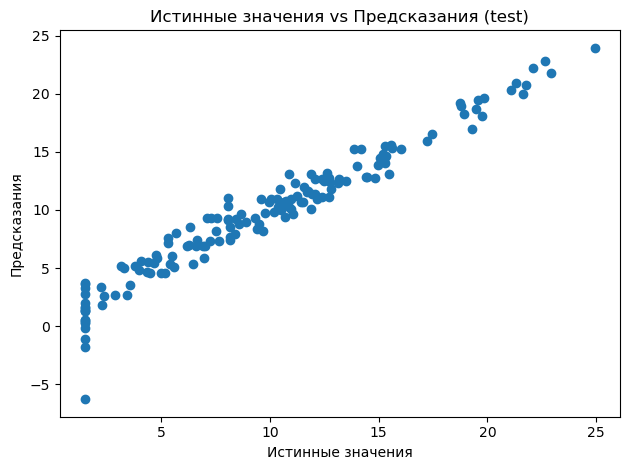

In [25]:
# Ячейка 8. Метрики качества
if MODEL_TYPE == 'classification':
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)
    print(f'Accuracy (train): {train_acc:.4f}')
    print(f'Accuracy (test) : {test_acc:.4f}')
    
    cm = confusion_matrix(y_test, y_test_pred)
    print('\nConfusion matrix (test):')
    display(pd.DataFrame(cm))
    
    plt.figure()
    plt.imshow(cm)
    plt.title('Матрица несоответствий (test)')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.show()
else:
    mse  = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_test_pred)
    print(f'MSE : {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE : {mae:.4f}')
    
    plt.figure()
    plt.scatter(y_test, y_test_pred)
    plt.title('Истинные значения vs Предсказания (test)')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказания')
    plt.tight_layout()
    plt.show()

## 6. Анализ переобучения (overfitting) и обобщения (generalization)

Сравните качество на обучающей и тестовой выборках.

- Если на train качество существенно лучше, чем на test, это может быть признаком **переобучения**.
- Если качество низкое и на train, и на test — возможное **недообучение**.


### Ответ студента
1) Есть ли признаки переобучения? (Да/Нет) - Нет, явных признаков переобучения не наблюдается.

2) На чём основан вывод? (сравнение метрик train/test) - Модель линейной регрессии показывает достаточно небольшую ошибку на тестовой выборке:
* MSE = 1.7095
* RMSE = 1.3075
* MAE = 0.9494

Значения ошибок относительно небольшие по сравнению с диапазоном целевой переменной (1.5 – 24.9). Это говорит о том, что модель достаточно хорошо обобщает данные и способна делать разумные предсказания для новых объектов.

3) Какие 2–3 улучшения можно предложить?
* Добавить масштабирование признаков (StandardScaler) для повышения стабильности модели.
* Попробовать более сложные модели, например Random Forest или Gradient Boosting.
* Выполнить анализ важности признаков и удалить менее значимые признаки.

## 7. Итоговые выводы

Сформулируйте выводы:
1) Какая задача решалась?
2) Какие признаки и цель использовались?
3) Какое качество получилось и что оно означает?
4) Какие ограничения есть у модели?


### Ответ студента
- **Задача:** Решалась задача контролируемого обучения типа регрессии — предсказание числового значения целевой переменной.
- **Целевая переменная:** Целевой переменной выбран столбец target, который представляет числовой показатель (предположительно цену или рейтинг квартиры).
- **Модель:** Для обучения использовалась модель линейной регрессии (LinearRegression).
- **Метрики:** Качество модели оценивалось с помощью метрик регрессии:
  * MSE = 1.7095
  * RMSE = 1.3075
  * MAE = 0.9494
  
  Полученные значения показывают, что средняя ошибка предсказания составляет примерно около 1 единицы целевой переменной.
- **Вывод:** Модель линейной регрессии показала удовлетворительное качество предсказания и способна выявлять зависимости между характеристиками квартиры и целевой переменной. Однако линейная модель имеет ограничения и может не учитывать сложные нелинейные зависимости между признаками. Для повышения точности можно использовать более сложные модели машинного обучения.